In [1]:
# data tools and plotting
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PrecisionRecallDisplay

import mlflow
sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

class TSFE(BaseEstimator, TransformerMixin):
    def __init__(self, feature_cols,  feature_config):#, target_col='label1'):
        self.feature_cols = feature_cols
        #self.target_col = target_col
        self.feature_config = feature_config
    #==========
    def fit (self, X, y=None):
        return self
    #=============
    def _fill_Nan(self, df, feature_cols):
        
        df[feature_cols] = df[feature_cols].ffill().fillna(df[feature_cols].median()) # df[feature_cols].median()
        return df
    # ============
    def _ratio_featutre_gen(self, df, feature):
        
        df[f'{feature[0]}_{feature[1]}_ratio'] = df[feature[0]]/df[feature[1]]
        return df
    #=============
    def _multi_featutre_gen(self, df, feature):
        df[f'{feature[0]}_{feature[1]}_multi'] = df[feature[0]]*df[feature[1]]
        return df

    #=============== diff, lag, rolling
    def _diff_gen(self, df, feature, period):
        for p in period:
            df[f'{feature}_diff_{p}'] = (df[f'{feature}'].diff(p))#.fillna(df[f'{feature}_diff_{p}'].median())

        return df
    #===============
    def _lag_gen (self, df, feature, period):
        for p in period:
            df[f'{feature}_lag_{p}'] = (df[f'{feature}'].shift(p))#.fillna(df[f'{feature}_lag_{p}'].median())
        return df

    #===============
    def _rolling_std_gen (self, df, feature, period):
        for p in period:
            df[f'{feature}_roll_std_{p}'] = (df[f'{feature}'].rolling(window=pd.to_timedelta(p), closed='left').std())#.fillna(df[f'{feature}_roll_std_{p}'].median())# self not included, NAN->0
        return df

    #===============
    def _rolling_mean_residual_gen(self, df, feature, period):
        for p in period:
            df[f'{feature}_roll_mean_{p}'] = df[f'{feature}'].rolling(window=pd.to_timedelta(p), closed='left').mean()#.fillna(df[f'{feature}_roll_mean_{p}'].median()) # self not included
            df[f'{feature}_residual_{p}'] = df[f'{feature}']- df[f'{feature}_roll_mean_{p}']# self not included
        return df
    #================
    def _feature_eng_apply(self, df, config):
        for opt, params in config.items():
            cols = params['cols']
           # period = params.get('period') or params.get('periods', 1) # period's value -> periods's -> 1

            for feature in cols:
                if opt == 'diff':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._diff_gen(df, feature, period)
                elif opt == 'ratio':
                    df = self._ratio_featutre_gen(df, feature)
                elif opt == 'multi':
                    df = self._multi_featutre_gen(df, feature)
                elif opt == 'lag':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._lag_gen(df, feature, period)
                elif opt == 'roll_std':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._rolling_std_gen( df, feature, period)
                elif opt == 'roll_mean_res':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._rolling_mean_residual_gen(df, feature, period)
        return df 

    def transform(self, X):
        df = X.copy(deep=False)
        #df = self._fill_Nan(df, self.feature_cols)
        df = self._fill_Nan(df, self.feature_cols) # fill for original feature values
        #df = self._ratio_featutre_gen(df, self.feature_cols)
        df.index = pd.to_datetime(df.index)
        df = self._feature_eng_apply(df, self.feature_config)
        df = df.replace([np.inf, -np.inf], np.nan) # handle inf values, prevent Nan values
        df_columns = df.columns.tolist()
        df = self._fill_Nan(df, df_columns)

        floas_cols = df.select_dtypes(include=['float64']).columns
        df[floas_cols] = df[floas_cols].astype('float32')

        return df

In [3]:
#=========

mlflow.set_tracking_uri(
    "http://127.0.0.1:5000"
)
mlflow.sklearn.autolog()

mlflow.set_experiment('iscnan_flag')
#=============== i


<Experiment: artifact_location='mlflow-artifacts:/4', creation_time=1783888657611, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1783888657611, lifecycle_stage='active', name='iscnan_flag', tags={}, trace_location=None, workspace='default'>

In [2]:

feature_cols= [#'datetime', 
  #'tamb', , 'pamb' ,'tmod', 
  'psamp',
  'pflow',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', 'duration', #'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
       'last_std_ht', 'last_air_ht'
       #'is_ht_zero_and_C_Nan','is_normal_std', #'is_bad_std', 'is_protential_flagged_air'
       ]



feature_config ={
    'ratio':{'cols':[['CH4_area', 'CH4_w'],
                     ['CH4_w', 'CH4_ht'], ['CH4_skew', 'CH4_w'], ['CH4_w', 'duration'], ['CH4_end_time', 'CH4_start_time'], ['CH4_area', 'pflow']]}, # ratio do not have period, just a default
    'diff':{'cols': [#'CH4_area', 
                     'CH4_ht', 'CH4_end_time','CH4_start_time'#'CH4_rt',
                    ], 'periods':[1, 2]},
    'multi':{'cols':[['CH4_w', 'CH4_ht']]},
    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',
                   #'pflow',
                   'CH4_w','CH4_skew'], 'periods':[1,2]},

    'roll_std':{'cols': ['CH4_w', 'CH4_ht'], 'period':['14D','30D']},
    'roll_mean_res':{'cols':[#'CH4_rt', 'CH4_start_time','CH4_skew' 
                             'CH4_w', 'CH4_ht','CH4_end_time'], 'period': ['14D', '30D']}
}

In [3]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

df.columns.tolist()

df['only_std_ht'] = df['CH4_ht'].where(df['type'] == 'std')
air_median = df.loc[df['type']=='air', 'CH4_ht'].median()
df['last_std_ht'] = df['only_std_ht'].ffill().shift(1).fillna(air_median)

df['only_air_ht'] = df['CH4_ht'].where(df['type'] == 'air')
std_median = df.loc[df['type']=='std', 'CH4_ht'].median()
df['last_air_ht'] = df['only_air_ht'].ffill().shift(1).fillna(std_median)

In [4]:
df['last_air_ht'].head(20)

datetime
1994-02-16 14:29:00    151205.0
1994-02-16 14:49:00         0.0
1994-02-16 15:09:00         0.0
1994-02-16 15:29:00    190908.0
1994-02-16 18:00:00    151667.0
1994-02-16 18:20:00         0.0
1994-02-16 18:40:00         0.0
1994-02-16 19:00:00         0.0
1994-02-16 19:20:00         0.0
1994-02-16 19:40:00         0.0
1994-02-16 20:23:00         0.0
1994-02-16 20:43:00         0.0
1994-02-16 21:03:00         0.0
1994-02-16 21:24:00         0.0
1994-02-16 21:44:00         0.0
1994-02-16 22:04:00         0.0
1994-02-16 22:24:00         0.0
1994-02-16 22:44:00         0.0
1994-02-16 23:04:00         0.0
1994-02-16 23:24:00         0.0
Name: last_air_ht, dtype: float64

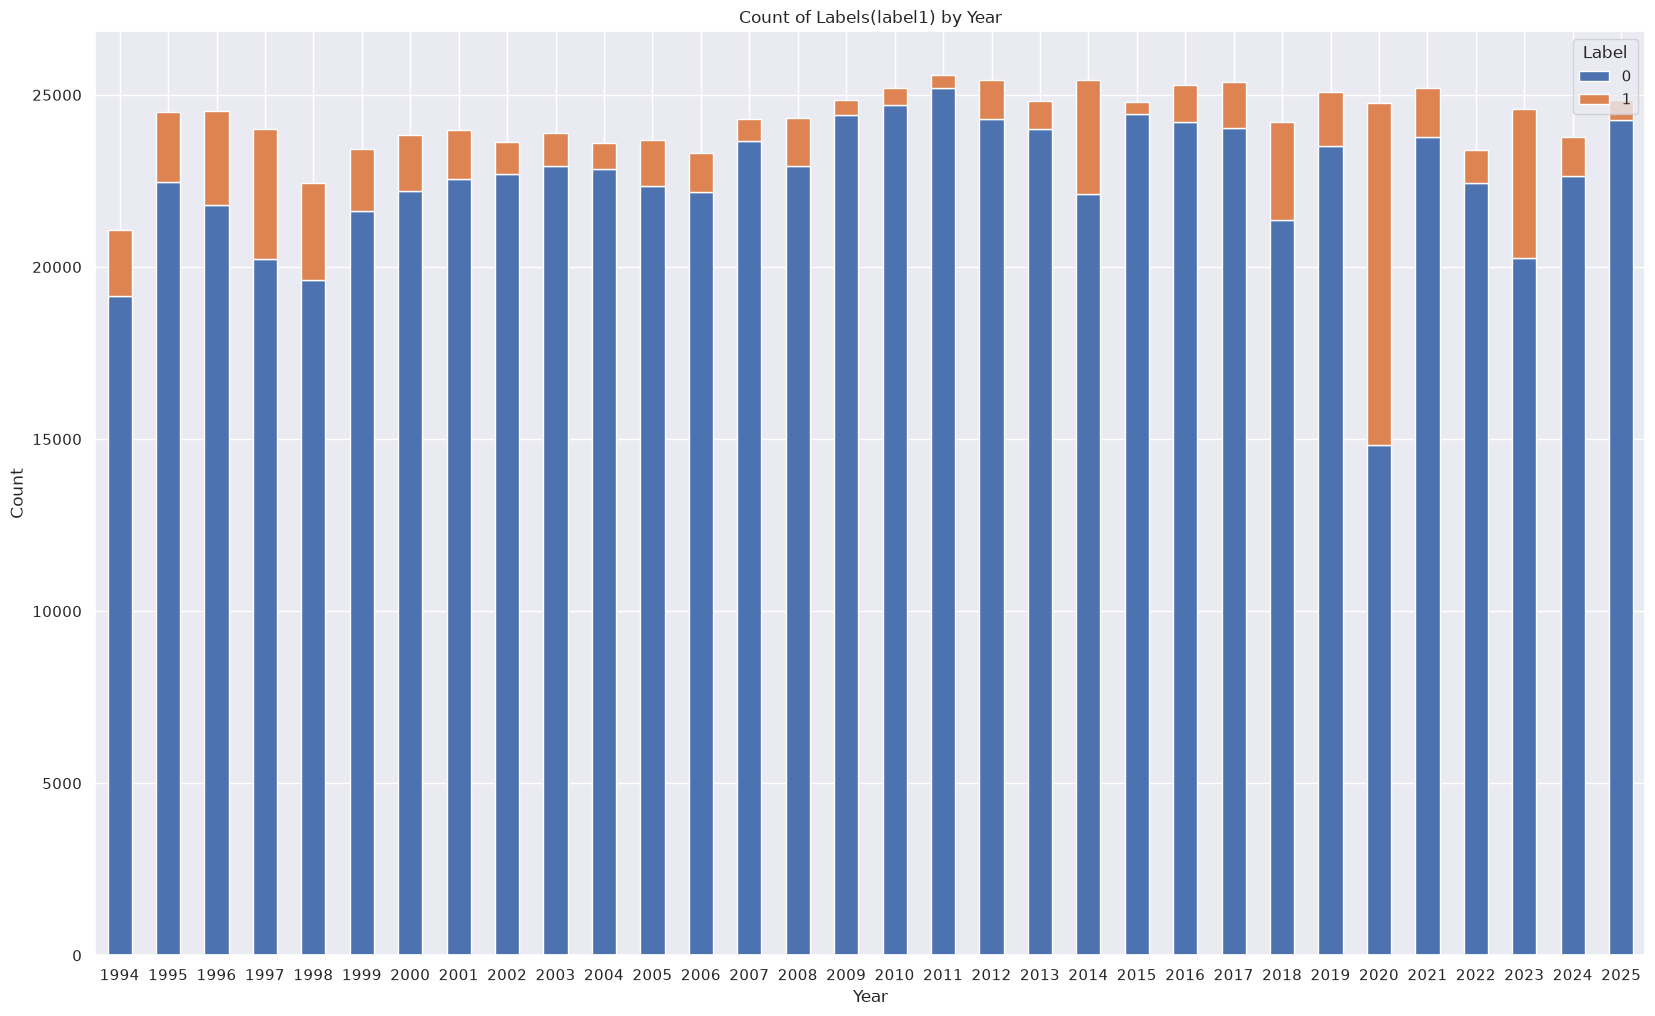

In [5]:
df_counts = pd.crosstab(df['year'], df['label_c_nan'])

ax = df_counts.plot(kind='bar', stacked=True, figsize=(20, 12))

plt.title('Count of Labels(label1) by Year')
plt.xlabel('Year')
plt.ylabel('Count')

plt.xticks(rotation=0)
plt.legend(title='Label')
plt.show()

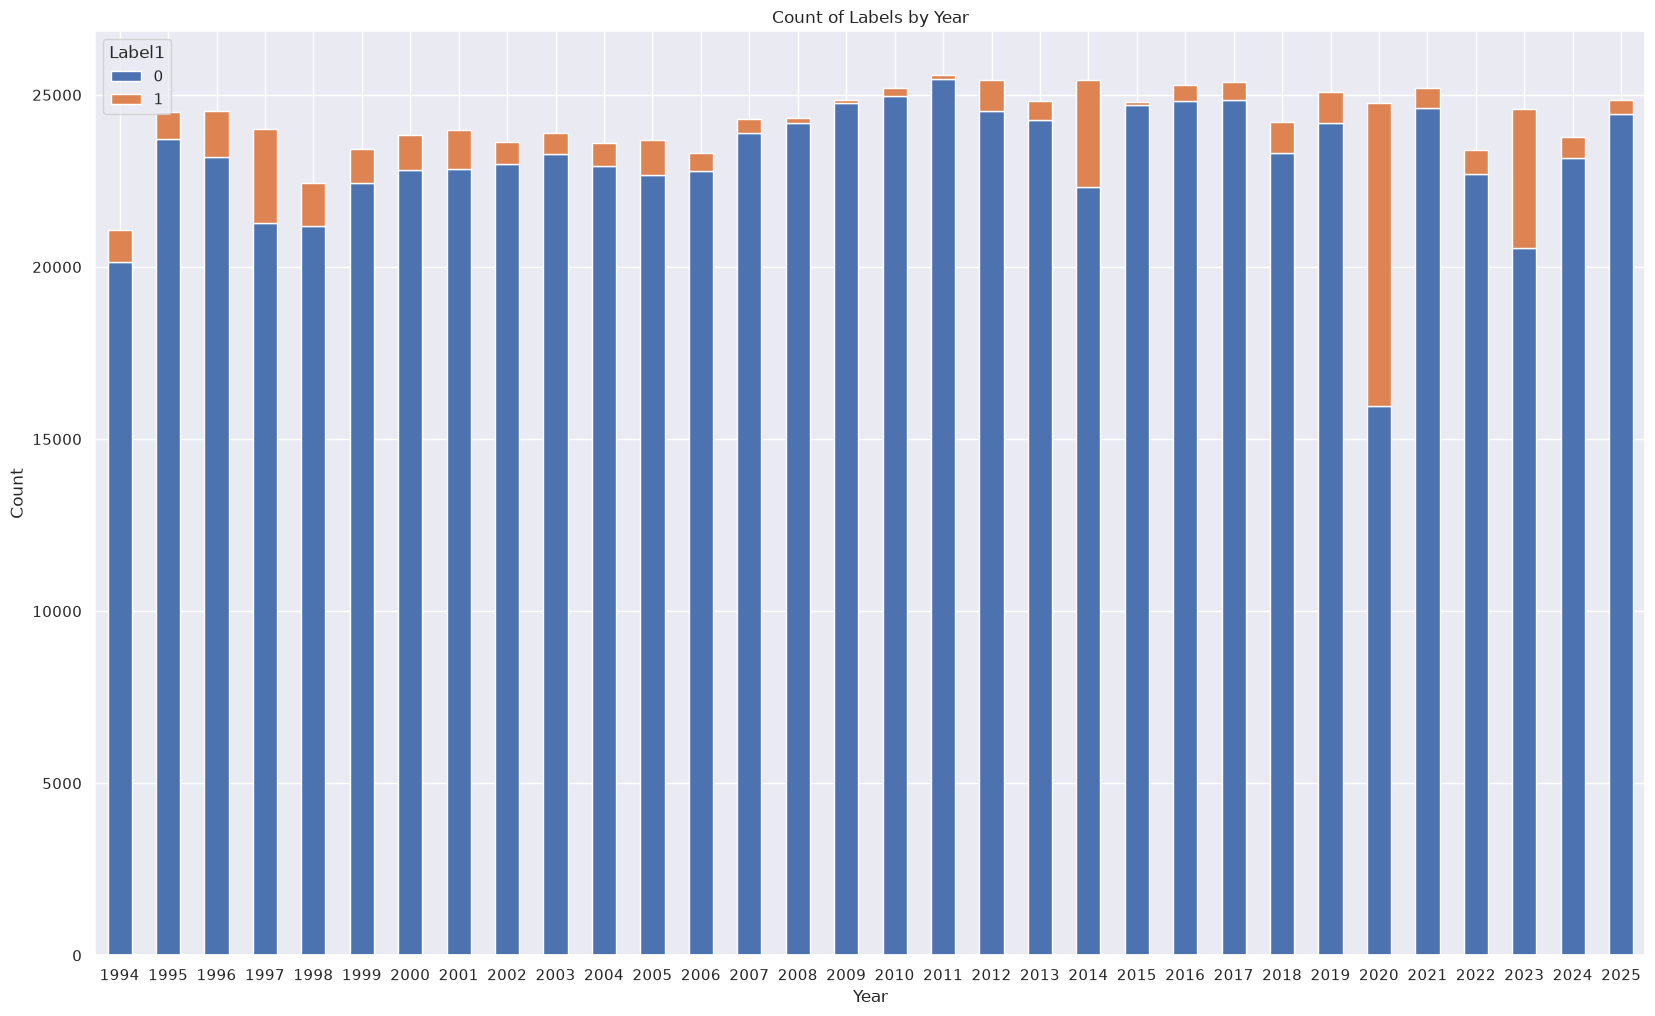

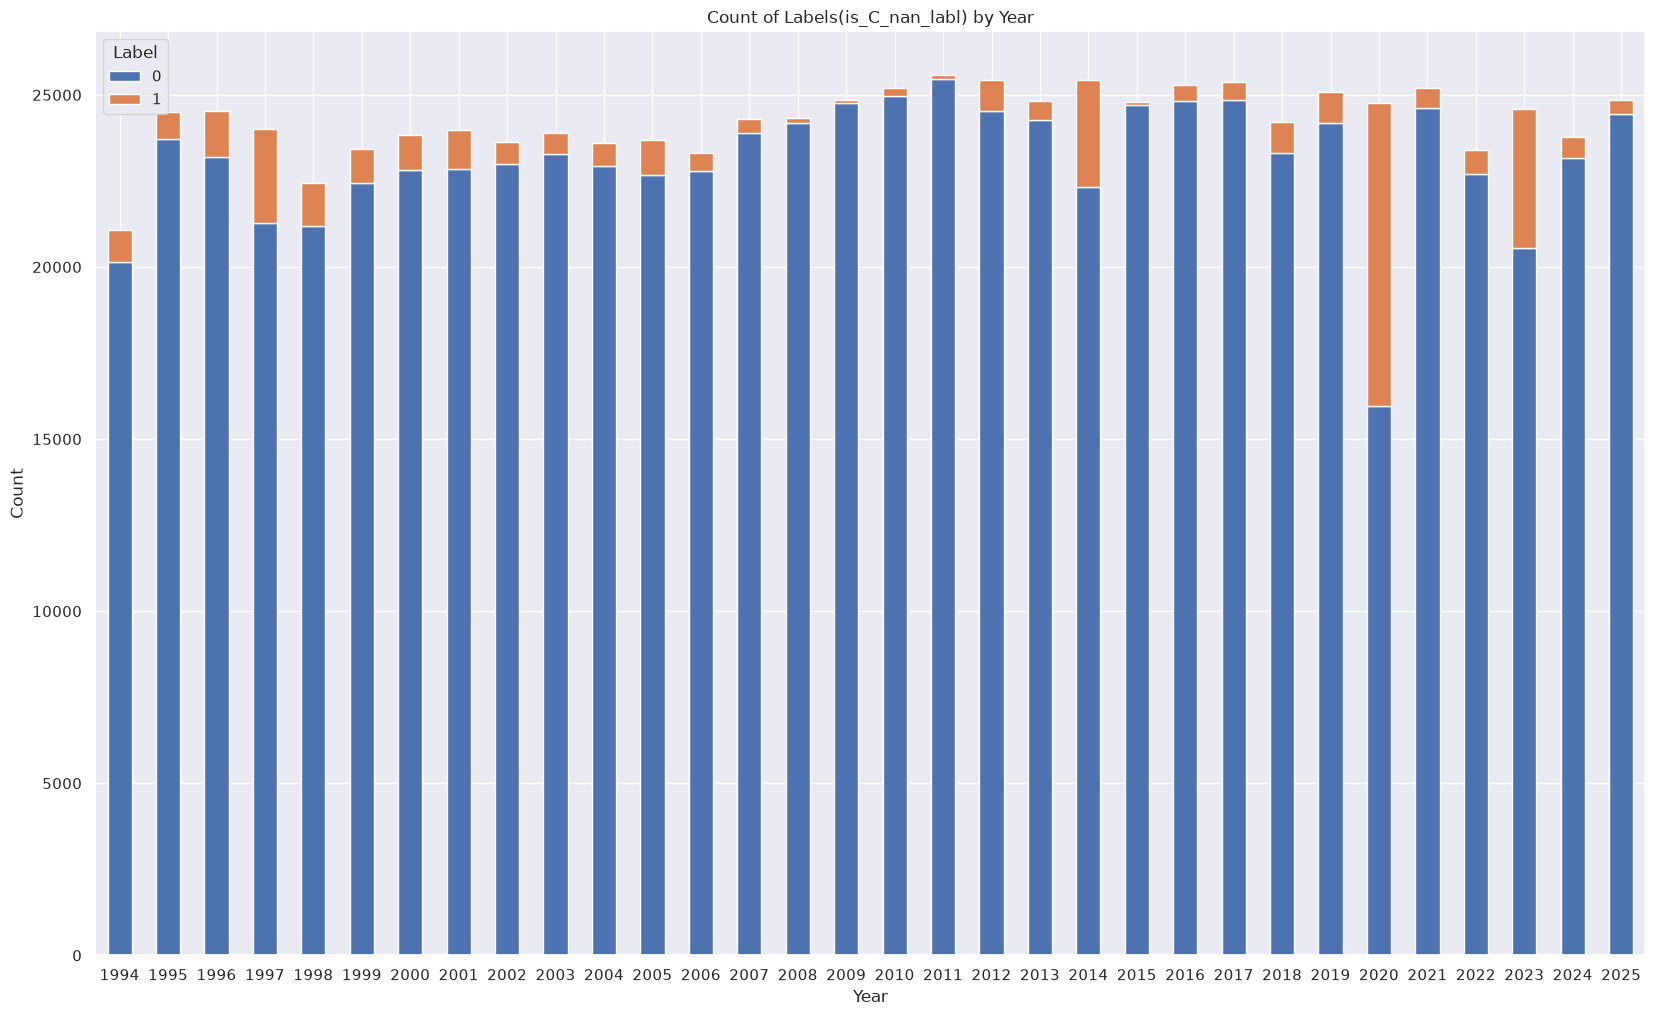

In [6]:
df_counts = pd.crosstab(df['year'], df['label1'])

ax = df_counts.plot(kind='bar', stacked=True, figsize=(20, 12))

plt.title('Count of Labels(is_C_nan_labl) by Year')
plt.xlabel('Year')
plt.ylabel('Count')

plt.xticks(rotation=0)
plt.legend(title='Label')
plt.show()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 777226 entries, 1994-02-16 14:29:00 to 2025-12-31 23:58:00
Data columns (total 75 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   date                    777226 non-null  int64  
 1   time                    777226 non-null  int64  
 2   type                    777226 non-null  object 
 3   sample                  777226 non-null  object 
 4   standard                777226 non-null  object 
 5   port                    777226 non-null  int64  
 6   ht                      777226 non-null  float64
 7   tmod                    672468 non-null  float64
 8   tamb                    672468 non-null  float64
 9   lab_temp                0 non-null       float64
 10  pflow                   775251 non-null  float64
 11  psamp                   775257 non-null  float64
 12  ploop                   0 non-null       float64
 13  pamb                    775198 non-null  float64

In [10]:
import shap
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)
pipe_rnd = Pipeline([
    #('scl', StandardScaler()),
    ('clf', RandomForestClassifier())
])

param_grid = {
    'clf__n_estimators': [100],
    'clf__max_depth': [5],
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':[2],
    'clf__max_features':['sqrt']
}
tscv = TimeSeriesSplit(n_splits=2)

In [11]:
df.index = pd.to_datetime(df.index)

In [ ]:
train_pderiod = pd.Timedelta(days=365)
test_period = pd.Timedelta(days=30)
step_size = pd.Timedelta(days=30)

feature_cols = feature_cols
label = 'label_c_nan'

start_time = df.index.min()
max_time = df.index.max()

current_train_start = start_time
results_list = []
all_period = current_train_start + train_pderiod + test_period
i = 0
with mlflow.start_run(run_name="0716_RF_ROLLING_MONTH BASED_v1") as parent_run:
    
    while all_period <= max_time:
        i += 1
        # set time zone
        current_train_end = current_train_start + train_pderiod
        current_test_end = current_train_end +  test_period

        train_df = df.loc[(df.index >= current_train_start) & (df.index < current_test_end)]
        test_df = df.loc[(df.index >= current_train_end) & (df.index < current_test_end)]
        
        # split data into X_train, y_train, X_test, y_test
        X_train, y_train = train_df[feature_cols], train_df[label]
        X_test, y_test = test_df[feature_cols], test_df[label]

        X_train_final = tsfe.fit_transform(X_train)
        y_train_final = y_train.copy()

        X_test_final = tsfe.transform(X_test)
        y_test_final = y_test.copy()
        if len(X_train_final)>0 and len(X_test_final)>0:
            if len(np.unique(y_train_final))>1: # more than 1 label than do the following
                #grid = GridSearchCV(estimator=pipe_rnd, param_grid = param_grid, cv=tscv,  scoring='average_precision', n_jobs=4, return_train_score=True)
                pipe_rnd.set_params(
                    clf__n_estimators= 100,
                    clf__max_depth= 5,
                    clf__class_weight='balanced',
                    clf__min_samples_leaf=2,
                    clf__max_features='sqrt'
                    ).fit(X_train_final, y_train_final)
                best_model = pipe_rnd

                y_pred = best_model.predict(X_test_final)

                rf_cls = best_model.named_steps['clf'].classes_ # to see how many class label in traing data, prevent the training data doesn't contain the anomaly(label as 1) data
                y_prob = best_model.predict_proba(X_test_final)[:, 1] if len(rf_cls)>1 else np.zeros(len(y_test_final))
            else:
                y_pred = np.zeros(len(y_test_final))
                y_prob = np.zeros(len(y_test_final))
        # anomaly probility

            result_df = pd.DataFrame({
                'y_true': y_test_final,
                'pred_label':y_pred,
                'pred_prob':y_prob,
                'window_id':i
            }, index=test_df.index)

            results_list.append(result_df)
            
        else:
            print(f"{current_train_start} to {current_train_end} is empty")
        current_train_start += step_size
        print('complete 1')
        all_period = current_train_start + train_pderiod + test_period
    all_results = pd.concat(results_list)


complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1
complete 1

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_true_all = all_results[label]
y_pred_all = all_results['pred_class']
y_prob_all = all_results['pred_prob']

print("===Evaluation report===")
print(classification_report(y_true_all, y_pred_all))

auc = roc_auc_score(y_true_all, y_prob_all)
print(f"Overall ROC_AUC: {auc:.5f}")



In [ ]:
weeks_performance = all_results.groupby('window_id').apply(
    lambda g: f1_score(g[label], g['pred_class'], ).reset_index(name='f1_score')
)

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(weeks_performance['window_id'], weeks_performance['f1_score'])
plt.title("F1-score during the period")
plt.xlabel("Window ID(weeks)")
plt.ylabel("F1-score")
plt.grid(True)
plt.savefig('image/f1-score_rolling.png')
plt.close()

In [ ]:
X = df[feature_cols]
y = df['label_c_nan']
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]



tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)


In [ ]:
import shap
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

X_train_final = tsfe.fit_transform(X_train)
y_train_final = y_train.copy()

pipe_rnd = Pipeline([
    #('scl', StandardScaler()),
    ('clf', RandomForestClassifier())
])

param_grid = {
    'clf__n_estimators': [120],
    'clf__max_depth': [5],
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':[2],
    'clf__max_features':['sqrt']
}

In [ ]:
X_train_final.columns

In [ ]:
with mlflow.start_run(run_name="0715_RF_GridSearch_120_type feature_v1") as parent_run:
    

In [ ]:
with mlflow.start_run(run_name="0715_RF_GridSearch_120_type feature_v1") as parent_run:
    
    grid = GridSearchCV(estimator=pipe_rnd, param_grid = param_grid, cv=tscv,  scoring='average_precision', n_jobs=4, return_train_score=True)
    grid.fit(X_train_final, y_train_final)

    # print best model score
    cv_results = pd.DataFrame(grid.cv_results_)
    best_index = grid.best_index_
    mean_train = cv_results.loc[best_index, 'mean_train_score']
    mean_test = cv_results.loc[best_index, 'mean_test_score']

    print(f"Best hyparameter set 5-fold mean training AP: {mean_train:.5f}")
    print(f"Best hyparameter set 5- fold mean validation set: {mean_test:.5f}")

        
    X_test_final = tsfe.fit_transform(X_test)
    y_test_final = y_test.copy()
    #=========== plotting
    #======== ROC
    RocCurveDisplay.from_estimator(grid, X_test_final, y_test_final)
    
    plt.title("ROC Curve via RocCurveDisplay")
    plt.plot([0, 1], [0,1], 'k--') 
    plt.savefig("image/ROC_Curve.png")
    mlflow.log_artifact("image/ROC_Curve.png")
    plt.show()    
    plt.close()
    # ======= PRC 
    PrecisionRecallDisplay.from_estimator(grid, X_test_final, y_test_final)

    plt.title("Precision-Recall Curve")
    plt.savefig("image/PRC_Curve.png")
    mlflow.log_artifact("image/PRC_Curve.png")
    plt.show()    
    plt.close()
    #========= SHAP
    best_pipeline = grid.best_estimator_
    final_rf_model = best_pipeline.named_steps['clf']


    explainer = shap.TreeExplainer(final_rf_model)
    shap_values = explainer(X_test_final)

    plt.figure(figsize=(10,15))
    shap.plots.beeswarm(shap_values[:, :, 1], max_display=46, show=False)
    plt.savefig("image/shap_summary.png")
    mlflow.log_artifact("image/shap_summary.png")
    plt.show()    
    plt.close()


print("All Done!")
    


    

    